In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder, StandardScaler, MinMaxScaler

In [2]:
df = pd.read_csv("A:\\iam_pikabyte\\CSV_Files&Pdf's\\titanic_data_updated.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,no,second,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,yes,first,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,no,third,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,yes,first,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
df.drop(['PassengerId','Name','Ticket'],axis=1,inplace=True)

In [4]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,no,third,male,22.0,1,0,7.2500,NaN,S
1,yes,first,female,38.0,1,0,71.2833,C85,C
2,yes,third,female,26.0,0,0,7.9250,NaN,S
3,yes,first,female,35.0,1,0,53.1000,C123,S
4,no,third,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...
886,no,second,male,27.0,0,0,13.0000,NaN,S
887,yes,first,female,19.0,0,0,30.0000,B42,S
888,no,third,female,NaN,1,2,23.4500,NaN,S
889,yes,first,male,26.0,0,0,30.0000,C148,C


In [5]:
# df.drop(['Cabin'],axis=1,inplace=True)
# df

In [6]:
X=df.drop(['Survived'],axis=1)
X

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,third,male,22.0,1,0,7.2500,NaN,S
1,first,female,38.0,1,0,71.2833,C85,C
2,third,female,26.0,0,0,7.9250,NaN,S
3,first,female,35.0,1,0,53.1000,C123,S
4,third,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...
886,second,male,27.0,0,0,13.0000,NaN,S
887,first,female,19.0,0,0,30.0000,B42,S
888,third,female,NaN,1,2,23.4500,NaN,S
889,first,male,26.0,0,0,30.0000,C148,C


In [7]:
y=df['Survived']
y

0       no
1      yes
2      yes
3      yes
4       no
      ... 
886     no
887    yes
888     no
889    yes
890     no
Name: Survived, Length: 891, dtype: object

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [9]:
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
331,first,male,45.5,0,0,28.5000,C124,S
733,second,male,23.0,0,0,13.0000,NaN,S
382,third,male,32.0,0,0,7.9250,NaN,S
704,third,male,26.0,1,0,7.8542,NaN,S
813,third,female,6.0,4,2,31.2750,NaN,S
...,...,...,...,...,...,...,...,...
106,third,female,21.0,0,0,7.6500,NaN,S
270,first,male,NaN,0,0,31.0000,NaN,S
860,third,male,41.0,2,0,14.1083,NaN,S
435,first,female,14.0,1,2,120.0000,B96 B98,S


Handling Missing Values

In [10]:
X_train.isnull().sum()

Pclass        0
Sex           0
Age         140
SibSp         0
Parch         0
Fare          0
Cabin       553
Embarked      2
dtype: int64

In [11]:
X_test.isnull().sum()

Pclass        0
Sex           0
Age          37
SibSp         0
Parch         0
Fare          0
Cabin       134
Embarked      0
dtype: int64

In [12]:
age_mean = X_train['Age'].mean()
age_mean

np.float64(29.498846153846156)

In [13]:
X_train['Age_mean_Imputor'] = X_train['Age'].fillna(age_mean)
X_test['Age_mean_Imputor'] = X_test['Age'].fillna(age_mean)

# Learn preprocessing parameters from X_train, then apply those same parameters to X_test. Using age_mean from test data will cause data leakage

In [14]:
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Age_mean_Imputor
331,first,male,45.5,0,0,28.5000,C124,S,45.500000
733,second,male,23.0,0,0,13.0000,NaN,S,23.000000
382,third,male,32.0,0,0,7.9250,NaN,S,32.000000
704,third,male,26.0,1,0,7.8542,NaN,S,26.000000
813,third,female,6.0,4,2,31.2750,NaN,S,6.000000
...,...,...,...,...,...,...,...,...,...
106,third,female,21.0,0,0,7.6500,NaN,S,21.000000
270,first,male,NaN,0,0,31.0000,NaN,S,29.498846
860,third,male,41.0,2,0,14.1083,NaN,S,41.000000
435,first,female,14.0,1,2,120.0000,B96 B98,S,14.000000


In [15]:
X_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Age_mean_Imputor
709,third,male,NaN,1,1,15.2458,NaN,C,29.498846
439,second,male,31.0,0,0,10.5000,NaN,S,31.000000
840,third,male,20.0,0,0,7.9250,NaN,S,20.000000
720,second,female,6.0,0,1,33.0000,NaN,S,6.000000
39,third,female,14.0,1,0,11.2417,NaN,C,14.000000
...,...,...,...,...,...,...,...,...,...
433,third,male,17.0,0,0,7.1250,NaN,S,17.000000
773,third,male,NaN,0,0,7.2250,NaN,C,29.498846
25,third,female,38.0,1,5,31.3875,NaN,S,38.000000
84,second,female,17.0,0,0,10.5000,NaN,S,17.000000


In [16]:
age_median = X_train['Age'].median()
X_train['age_median_imputor'] = X_train['Age'].fillna(age_median)
X_test['age_median_imputor'] = X_test['Age'].fillna(age_median)

In [17]:
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Age_mean_Imputor,age_median_imputor
331,first,male,45.5,0,0,28.5000,C124,S,45.500000,45.5
733,second,male,23.0,0,0,13.0000,NaN,S,23.000000,23.0
382,third,male,32.0,0,0,7.9250,NaN,S,32.000000,32.0
704,third,male,26.0,1,0,7.8542,NaN,S,26.000000,26.0
813,third,female,6.0,4,2,31.2750,NaN,S,6.000000,6.0
...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.0,0,0,7.6500,NaN,S,21.000000,21.0
270,first,male,NaN,0,0,31.0000,NaN,S,29.498846,28.0
860,third,male,41.0,2,0,14.1083,NaN,S,41.000000,41.0
435,first,female,14.0,1,2,120.0000,B96 B98,S,14.000000,14.0


In [18]:
X_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Age_mean_Imputor,age_median_imputor
709,third,male,NaN,1,1,15.2458,NaN,C,29.498846,28.0
439,second,male,31.0,0,0,10.5000,NaN,S,31.000000,31.0
840,third,male,20.0,0,0,7.9250,NaN,S,20.000000,20.0
720,second,female,6.0,0,1,33.0000,NaN,S,6.000000,6.0
39,third,female,14.0,1,0,11.2417,NaN,C,14.000000,14.0
...,...,...,...,...,...,...,...,...,...,...
433,third,male,17.0,0,0,7.1250,NaN,S,17.000000,17.0
773,third,male,NaN,0,0,7.2250,NaN,C,29.498846,28.0
25,third,female,38.0,1,5,31.3875,NaN,S,38.000000,38.0
84,second,female,17.0,0,0,10.5000,NaN,S,17.000000,17.0


<Axes: xlabel='Age_mean_Imputor', ylabel='Density'>

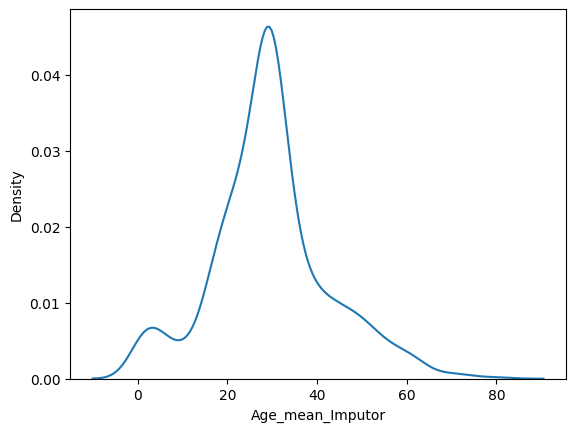

In [19]:
sns.kdeplot(data = X_train, x=X_train['Age_mean_Imputor'] )

<Axes: xlabel='Age_mean_Imputor', ylabel='Density'>

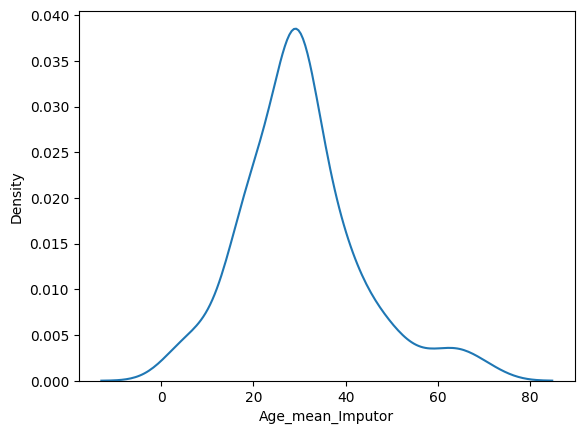

In [20]:
sns.kdeplot(data = X_train, x=X_test['Age_mean_Imputor'] )

## Simple Imputor

In [21]:
age_imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
age_imputer.fit(X_train[['Age']])
X_train['Age'] = age_imputer.transform(X_train[['Age']])

In [22]:
X_train.isnull().sum()

Pclass                  0
Sex                     0
Age                     0
SibSp                   0
Parch                   0
Fare                    0
Cabin                 553
Embarked                2
Age_mean_Imputor        0
age_median_imputor      0
dtype: int64

In [23]:
X_train.drop(['Age_mean_Imputor', 'age_median_imputor'], axis=1, inplace=True)
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
331,first,male,45.500000,0,0,28.5000,C124,S
733,second,male,23.000000,0,0,13.0000,NaN,S
382,third,male,32.000000,0,0,7.9250,NaN,S
704,third,male,26.000000,1,0,7.8542,NaN,S
813,third,female,6.000000,4,2,31.2750,NaN,S
...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,NaN,S
270,first,male,29.498846,0,0,31.0000,NaN,S
860,third,male,41.000000,2,0,14.1083,NaN,S
435,first,female,14.000000,1,2,120.0000,B96 B98,S


In [24]:
X_test.drop(['Age_mean_Imputor', 'age_median_imputor'], axis=1, inplace=True)
X_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
709,third,male,NaN,1,1,15.2458,NaN,C
439,second,male,31.0,0,0,10.5000,NaN,S
840,third,male,20.0,0,0,7.9250,NaN,S
720,second,female,6.0,0,1,33.0000,NaN,S
39,third,female,14.0,1,0,11.2417,NaN,C
...,...,...,...,...,...,...,...,...
433,third,male,17.0,0,0,7.1250,NaN,S
773,third,male,NaN,0,0,7.2250,NaN,C
25,third,female,38.0,1,5,31.3875,NaN,S
84,second,female,17.0,0,0,10.5000,NaN,S


In [25]:
X_test['Age'] = age_imputer.transform(X_test[['Age']])
X_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
709,third,male,29.498846,1,1,15.2458,NaN,C
439,second,male,31.000000,0,0,10.5000,NaN,S
840,third,male,20.000000,0,0,7.9250,NaN,S
720,second,female,6.000000,0,1,33.0000,NaN,S
39,third,female,14.000000,1,0,11.2417,NaN,C
...,...,...,...,...,...,...,...,...
433,third,male,17.000000,0,0,7.1250,NaN,S
773,third,male,29.498846,0,0,7.2250,NaN,C
25,third,female,38.000000,1,5,31.3875,NaN,S
84,second,female,17.000000,0,0,10.5000,NaN,S


In [26]:
embarked_imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
embarked_imputer.fit(X_train[['Embarked']])
X_train['Embarked']= embarked_imputer.transform(X_train[['Embarked']]).ravel()
X_test['Embarked'] = embarked_imputer.transform(X_test[['Embarked']]).ravel()

In [27]:
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
331,first,male,45.500000,0,0,28.5000,C124,S
733,second,male,23.000000,0,0,13.0000,NaN,S
382,third,male,32.000000,0,0,7.9250,NaN,S
704,third,male,26.000000,1,0,7.8542,NaN,S
813,third,female,6.000000,4,2,31.2750,NaN,S
...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,NaN,S
270,first,male,29.498846,0,0,31.0000,NaN,S
860,third,male,41.000000,2,0,14.1083,NaN,S
435,first,female,14.000000,1,2,120.0000,B96 B98,S


In [28]:
X_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
709,third,male,29.498846,1,1,15.2458,NaN,C
439,second,male,31.000000,0,0,10.5000,NaN,S
840,third,male,20.000000,0,0,7.9250,NaN,S
720,second,female,6.000000,0,1,33.0000,NaN,S
39,third,female,14.000000,1,0,11.2417,NaN,C
...,...,...,...,...,...,...,...,...
433,third,male,17.000000,0,0,7.1250,NaN,S
773,third,male,29.498846,0,0,7.2250,NaN,C
25,third,female,38.000000,1,5,31.3875,NaN,S
84,second,female,17.000000,0,0,10.5000,NaN,S


In [29]:
X_train.isnull().sum()

Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Cabin       553
Embarked      0
dtype: int64

In [30]:
cabin_imputer = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='Missing', add_indicator=True)
cabin_imputer.fit(X_train[['Cabin']])

X_train[['Cabin', 'Cabin_missing_indicator']] = cabin_imputer.transform(X_train[['Cabin']])
X_test[['Cabin', 'Cabin_missing_indicator']] = cabin_imputer.transform(X_test[['Cabin']])


In [31]:
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Cabin_missing_indicator
331,first,male,45.500000,0,0,28.5000,C124,S,False
733,second,male,23.000000,0,0,13.0000,Missing,S,True
382,third,male,32.000000,0,0,7.9250,Missing,S,True
704,third,male,26.000000,1,0,7.8542,Missing,S,True
813,third,female,6.000000,4,2,31.2750,Missing,S,True
...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True
270,first,male,29.498846,0,0,31.0000,Missing,S,True
860,third,male,41.000000,2,0,14.1083,Missing,S,True
435,first,female,14.000000,1,2,120.0000,B96 B98,S,False


In [32]:
X_train.isnull().sum()

Pclass                     0
Sex                        0
Age                        0
SibSp                      0
Parch                      0
Fare                       0
Cabin                      0
Embarked                   0
Cabin_missing_indicator    0
dtype: int64

In [33]:
print(age_imputer.statistics_)

[29.49884615]


## Using Z-Score

In [34]:
mean_of_age = X_train['Age'].mean()
std_of_age = X_train['Age'].std()

X_train['z_score_age'] = (X_train['Age'] - mean_of_age)/std_of_age
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Cabin_missing_indicator,z_score_age
331,first,male,45.500000,0,0,28.5000,C124,S,False,1.231398e+00
733,second,male,23.000000,0,0,13.0000,Missing,S,True,-5.001304e-01
382,third,male,32.000000,0,0,7.9250,Missing,S,True,1.924808e-01
704,third,male,26.000000,1,0,7.8542,Missing,S,True,-2.692600e-01
813,third,female,6.000000,4,2,31.2750,Missing,S,True,-1.808396e+00
...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True,-6.540440e-01
270,first,male,29.498846,0,0,31.0000,Missing,S,True,2.734055e-16
860,third,male,41.000000,2,0,14.1083,Missing,S,True,8.850920e-01
435,first,female,14.000000,1,2,120.0000,B96 B98,S,False,-1.192742e+00


In [35]:
outliers = X_train[abs(X_train['z_score_age']) > 3]
print(outliers)

     Pclass   Sex   Age  SibSp  Parch    Fare    Cabin Embarked  \
116   third  male  70.5      0      0   7.750  Missing        Q   
745   first  male  70.0      1      1  71.000      B22        S   
630   first  male  80.0      0      0  30.000      A23        S   
851   third  male  74.0      0      0   7.775  Missing        S   
672  second  male  70.0      0      0  10.500  Missing        S   

    Cabin_missing_indicator  z_score_age  
116                    True     3.155317  
745                   False     3.116839  
630                   False     3.886407  
851                    True     3.424666  
672                    True     3.116839  


In [36]:
mean_of_fare = X_train['Fare'].mean()
std_of_fare = X_train['Fare'].std()

X_train['z_score_fare'] = (X_train['Fare'] - mean_of_fare)/std_of_fare
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Cabin_missing_indicator,z_score_age,z_score_fare
331,first,male,45.500000,0,0,28.5000,C124,S,False,1.231398e+00,-0.078628
733,second,male,23.000000,0,0,13.0000,Missing,S,True,-5.001304e-01,-0.376880
382,third,male,32.000000,0,0,7.9250,Missing,S,True,1.924808e-01,-0.474533
704,third,male,26.000000,1,0,7.8542,Missing,S,True,-2.692600e-01,-0.475896
813,third,female,6.000000,4,2,31.2750,Missing,S,True,-1.808396e+00,-0.025232
...,...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True,-6.540440e-01,-0.479825
270,first,male,29.498846,0,0,31.0000,Missing,S,True,2.734055e-16,-0.030523
860,third,male,41.000000,2,0,14.1083,Missing,S,True,8.850920e-01,-0.355554
435,first,female,14.000000,1,2,120.0000,B96 B98,S,False,-1.192742e+00,1.682019


In [37]:
outliers_fare = X_train[abs(X_train['z_score_fare']) > 3]
print(outliers_fare)

    Pclass     Sex        Age  SibSp  Parch      Fare            Cabin  \
118  first    male  24.000000      0      1  247.5208          B58 B60   
716  first  female  38.000000      0      0  227.5250              C45   
377  first    male  27.000000      0      2  211.5000              C82   
742  first  female  21.000000      2      2  262.3750  B57 B59 B63 B66   
380  first  female  42.000000      0      0  227.5250          Missing   
779  first  female  43.000000      0      1  211.3375               B3   
730  first  female  29.000000      0      0  211.3375               B5   
88   first  female  23.000000      3      2  263.0000      C23 C25 C27   
341  first  female  24.000000      3      2  263.0000      C23 C25 C27   
557  first    male  29.498846      0      0  227.5250          Missing   
737  first    male  35.000000      0      0  512.3292             B101   
679  first    male  36.000000      0      1  512.3292      B51 B53 B55   
438  first    male  64.000000      1  

## Outliers with IQR

In [38]:
age_Q1 = X_train['Age'].quantile(0.25)
age_Q3 = X_train['Age'].quantile(0.75)

age_IQR = age_Q3 - age_Q1

age_minimum = age_Q1 - 1.5*age_IQR
age_maximum = age_Q3 + 1.5*age_IQR

print("Age Minimum:",age_minimum, "\nAge Maximum:",age_maximum)

Age Minimum: 2.5 
Age Maximum: 54.5


In [39]:
age_outlier_IQR = X_train[(X_train['Age'] < age_minimum)|(X_train['Age']>age_maximum)]
print(len(age_outlier_IQR))
display(age_outlier_IQR)

54


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Cabin_missing_indicator,z_score_age,z_score_fare
326,third,male,61.00,0,0,6.2375,Missing,S,True,2.424228,-0.507004
483,third,female,63.00,0,0,9.5875,Missing,S,True,2.578141,-0.442543
7,third,male,2.00,3,1,21.0750,Missing,S,True,-2.116223,-0.221500
305,first,male,0.92,1,2,151.5500,C22 C26,S,False,-2.199336,2.289105
829,first,female,62.00,0,0,80.0000,B28,S,False,2.501185,0.912337
626,second,male,57.00,0,0,12.3500,Missing,Q,True,2.116401,-0.389387
456,first,male,65.00,0,0,26.5500,E38,S,False,2.732055,-0.116150
172,third,female,1.00,1,1,11.1333,Missing,S,True,-2.193180,-0.412799
164,third,male,1.00,4,1,39.6875,Missing,S,True,-2.193180,0.136642
381,third,female,1.00,0,2,15.7417,Missing,C,True,-2.193180,-0.324124


In [40]:
fare_Q1 = X_train['Fare'].quantile(0.25)
fare_Q3 = X_train['Fare'].quantile(0.75)

fare_IQR = fare_Q3 - fare_Q1

fare_minimum = max(0,fare_Q1 - 1.5*fare_IQR)
fare_maximum = fare_Q3 + 1.5*fare_IQR

print("Minimum Fare:", fare_minimum, "\nMaximum Fare:", fare_maximum)

Minimum Fare: 0 
Maximum Fare: 64.3625


In [41]:
fare_outliers = X_train[(X_train['Fare'] < fare_minimum) | (X_train['Fare'] > fare_maximum)]
print(len(fare_outliers))
display(fare_outliers)

96


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Cabin_missing_indicator,z_score_age,z_score_fare
118,first,male,24.0,0,1,247.5208,B58 B60,C,False,-0.423174,4.135780
486,first,female,35.0,1,0,90.0000,C93,S,False,0.423351,1.104757
716,first,female,38.0,0,0,227.5250,C45,C,False,0.654222,3.751020
390,first,male,36.0,1,2,120.0000,B96 B98,S,False,0.500308,1.682019
377,first,male,27.0,0,2,211.5000,C82,C,False,-0.192303,3.442666
...,...,...,...,...,...,...,...,...,...,...,...
681,first,male,27.0,0,0,76.7292,D49,C,False,-0.192303,0.849400
385,second,male,18.0,0,0,73.5000,Missing,S,True,-0.884914,0.787264
700,first,female,18.0,1,0,227.5250,C62 C64,C,False,-0.884914,3.751020
435,first,female,14.0,1,2,120.0000,B96 B98,S,False,-1.192742,1.682019


In [42]:
X_train = X_train[abs(X_train['z_score_age']) <= 3]
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Cabin_missing_indicator,z_score_age,z_score_fare
331,first,male,45.500000,0,0,28.5000,C124,S,False,1.231398e+00,-0.078628
733,second,male,23.000000,0,0,13.0000,Missing,S,True,-5.001304e-01,-0.376880
382,third,male,32.000000,0,0,7.9250,Missing,S,True,1.924808e-01,-0.474533
704,third,male,26.000000,1,0,7.8542,Missing,S,True,-2.692600e-01,-0.475896
813,third,female,6.000000,4,2,31.2750,Missing,S,True,-1.808396e+00,-0.025232
...,...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True,-6.540440e-01,-0.479825
270,first,male,29.498846,0,0,31.0000,Missing,S,True,2.734055e-16,-0.030523
860,third,male,41.000000,2,0,14.1083,Missing,S,True,8.850920e-01,-0.355554
435,first,female,14.000000,1,2,120.0000,B96 B98,S,False,-1.192742e+00,1.682019


In [43]:
X_train['Fare'] = X_train['Fare'].clip(fare_minimum, fare_maximum)
X_train['Fare'].max()

C:\Users\Pikachu\AppData\Local\Temp\ipykernel_9028\2216021471.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['Fare'] = X_train['Fare'].clip(fare_minimum, fare_maximum)


np.float64(64.3625)

In [44]:
X_train.drop(['z_score_age', 'z_score_fare'], axis=1, inplace=True)

C:\Users\Pikachu\AppData\Local\Temp\ipykernel_9028\712109783.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train.drop(['z_score_age', 'z_score_fare'], axis=1, inplace=True)


In [45]:
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Cabin_missing_indicator
331,first,male,45.500000,0,0,28.5000,C124,S,False
733,second,male,23.000000,0,0,13.0000,Missing,S,True
382,third,male,32.000000,0,0,7.9250,Missing,S,True
704,third,male,26.000000,1,0,7.8542,Missing,S,True
813,third,female,6.000000,4,2,31.2750,Missing,S,True
...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True
270,first,male,29.498846,0,0,31.0000,Missing,S,True
860,third,male,41.000000,2,0,14.1083,Missing,S,True
435,first,female,14.000000,1,2,64.3625,B96 B98,S,False


In [46]:
X_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Cabin_missing_indicator
709,third,male,29.498846,1,1,15.2458,Missing,C,True
439,second,male,31.000000,0,0,10.5000,Missing,S,True
840,third,male,20.000000,0,0,7.9250,Missing,S,True
720,second,female,6.000000,0,1,33.0000,Missing,S,True
39,third,female,14.000000,1,0,11.2417,Missing,C,True
...,...,...,...,...,...,...,...,...,...
433,third,male,17.000000,0,0,7.1250,Missing,S,True
773,third,male,29.498846,0,0,7.2250,Missing,C,True
25,third,female,38.000000,1,5,31.3875,Missing,S,True
84,second,female,17.000000,0,0,10.5000,Missing,S,True


## Ordinal Encoder

In [47]:
pclass_encoder = OrdinalEncoder(categories=[['third', 'second','first']])

pclass_encoder.fit(X_train[['Pclass']])

X_train['encoded_pclass'] = pclass_encoder.transform(X_train[['Pclass']]).ravel()
X_test['encoded_pclass'] = pclass_encoder.transform(X_test[['Pclass']]).ravel()

X_train

C:\Users\Pikachu\AppData\Local\Temp\ipykernel_9028\2782104662.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['encoded_pclass'] = pclass_encoder.transform(X_train[['Pclass']]).ravel()


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Cabin_missing_indicator,encoded_pclass
331,first,male,45.500000,0,0,28.5000,C124,S,False,2.0
733,second,male,23.000000,0,0,13.0000,Missing,S,True,1.0
382,third,male,32.000000,0,0,7.9250,Missing,S,True,0.0
704,third,male,26.000000,1,0,7.8542,Missing,S,True,0.0
813,third,female,6.000000,4,2,31.2750,Missing,S,True,0.0
...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True,0.0
270,first,male,29.498846,0,0,31.0000,Missing,S,True,2.0
860,third,male,41.000000,2,0,14.1083,Missing,S,True,0.0
435,first,female,14.000000,1,2,64.3625,B96 B98,S,False,2.0


## OneHotEncoder

In [48]:
sex_ohe = OneHotEncoder(sparse_output=False).set_output(transform='pandas')

sex_ohe.fit(X_train[['Sex']])
encoded_df = sex_ohe.transform(X_train[['Sex']])

X_train = pd.concat([X_train, encoded_df], axis=1)

X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Cabin_missing_indicator,encoded_pclass,Sex_female,Sex_male
331,first,male,45.500000,0,0,28.5000,C124,S,False,2.0,0.0,1.0
733,second,male,23.000000,0,0,13.0000,Missing,S,True,1.0,0.0,1.0
382,third,male,32.000000,0,0,7.9250,Missing,S,True,0.0,0.0,1.0
704,third,male,26.000000,1,0,7.8542,Missing,S,True,0.0,0.0,1.0
813,third,female,6.000000,4,2,31.2750,Missing,S,True,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True,0.0,1.0,0.0
270,first,male,29.498846,0,0,31.0000,Missing,S,True,2.0,0.0,1.0
860,third,male,41.000000,2,0,14.1083,Missing,S,True,0.0,0.0,1.0
435,first,female,14.000000,1,2,64.3625,B96 B98,S,False,2.0,1.0,0.0


In [49]:
embarked_ohe = OneHotEncoder(sparse_output=False).set_output(transform='pandas')

embarked_ohe.fit(X_train[['Embarked']])
encoded_df = embarked_ohe.transform(X_train[['Embarked']])

X_train = pd.concat([X_train, encoded_df], axis=1)

X_train


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Cabin_missing_indicator,encoded_pclass,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
331,first,male,45.500000,0,0,28.5000,C124,S,False,2.0,0.0,1.0,0.0,0.0,1.0
733,second,male,23.000000,0,0,13.0000,Missing,S,True,1.0,0.0,1.0,0.0,0.0,1.0
382,third,male,32.000000,0,0,7.9250,Missing,S,True,0.0,0.0,1.0,0.0,0.0,1.0
704,third,male,26.000000,1,0,7.8542,Missing,S,True,0.0,0.0,1.0,0.0,0.0,1.0
813,third,female,6.000000,4,2,31.2750,Missing,S,True,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True,0.0,1.0,0.0,0.0,0.0,1.0
270,first,male,29.498846,0,0,31.0000,Missing,S,True,2.0,0.0,1.0,0.0,0.0,1.0
860,third,male,41.000000,2,0,14.1083,Missing,S,True,0.0,0.0,1.0,0.0,0.0,1.0
435,first,female,14.000000,1,2,64.3625,B96 B98,S,False,2.0,1.0,0.0,0.0,0.0,1.0


In [50]:
X_train.drop(['Sex','Pclass','Embarked'], axis=1, inplace=True)
X_train

,Age,SibSp,Parch,Fare,Cabin,Cabin_missing_indicator,encoded_pclass,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
331,45.500000,0,0,28.5000,C124,False,2.0,0.0,1.0,0.0,0.0,1.0
733,23.000000,0,0,13.0000,Missing,True,1.0,0.0,1.0,0.0,0.0,1.0
382,32.000000,0,0,7.9250,Missing,True,0.0,0.0,1.0,0.0,0.0,1.0
704,26.000000,1,0,7.8542,Missing,True,0.0,0.0,1.0,0.0,0.0,1.0
813,6.000000,4,2,31.2750,Missing,True,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
106,21.000000,0,0,7.6500,Missing,True,0.0,1.0,0.0,0.0,0.0,1.0
270,29.498846,0,0,31.0000,Missing,True,2.0,0.0,1.0,0.0,0.0,1.0
860,41.000000,2,0,14.1083,Missing,True,0.0,0.0,1.0,0.0,0.0,1.0
435,14.000000,1,2,64.3625,B96 B98,False,2.0,1.0,0.0,0.0,0.0,1.0


In [51]:
encoded_df = embarked_ohe.transform(X_test[['Embarked']])

X_test = pd.concat([X_test, encoded_df], axis=1)

X_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Cabin_missing_indicator,encoded_pclass,Embarked_C,Embarked_Q,Embarked_S
709,third,male,29.498846,1,1,15.2458,Missing,C,True,0.0,1.0,0.0,0.0
439,second,male,31.000000,0,0,10.5000,Missing,S,True,1.0,0.0,0.0,1.0
840,third,male,20.000000,0,0,7.9250,Missing,S,True,0.0,0.0,0.0,1.0
720,second,female,6.000000,0,1,33.0000,Missing,S,True,1.0,0.0,0.0,1.0
39,third,female,14.000000,1,0,11.2417,Missing,C,True,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
433,third,male,17.000000,0,0,7.1250,Missing,S,True,0.0,0.0,0.0,1.0
773,third,male,29.498846,0,0,7.2250,Missing,C,True,0.0,1.0,0.0,0.0
25,third,female,38.000000,1,5,31.3875,Missing,S,True,0.0,0.0,0.0,1.0
84,second,female,17.000000,0,0,10.5000,Missing,S,True,1.0,0.0,0.0,1.0


In [52]:
encoded_df = sex_ohe.transform(X_test[['Sex']])

X_test = pd.concat([X_test, encoded_df], axis=1)

X_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Cabin_missing_indicator,encoded_pclass,Embarked_C,Embarked_Q,Embarked_S,Sex_female,Sex_male
709,third,male,29.498846,1,1,15.2458,Missing,C,True,0.0,1.0,0.0,0.0,0.0,1.0
439,second,male,31.000000,0,0,10.5000,Missing,S,True,1.0,0.0,0.0,1.0,0.0,1.0
840,third,male,20.000000,0,0,7.9250,Missing,S,True,0.0,0.0,0.0,1.0,0.0,1.0
720,second,female,6.000000,0,1,33.0000,Missing,S,True,1.0,0.0,0.0,1.0,1.0,0.0
39,third,female,14.000000,1,0,11.2417,Missing,C,True,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433,third,male,17.000000,0,0,7.1250,Missing,S,True,0.0,0.0,0.0,1.0,0.0,1.0
773,third,male,29.498846,0,0,7.2250,Missing,C,True,0.0,1.0,0.0,0.0,0.0,1.0
25,third,female,38.000000,1,5,31.3875,Missing,S,True,0.0,0.0,0.0,1.0,1.0,0.0
84,second,female,17.000000,0,0,10.5000,Missing,S,True,1.0,0.0,0.0,1.0,1.0,0.0


In [53]:
X_test.drop(['Sex','Pclass','Embarked'], axis=1, inplace=True)
X_test

,Age,SibSp,Parch,Fare,Cabin,Cabin_missing_indicator,encoded_pclass,Embarked_C,Embarked_Q,Embarked_S,Sex_female,Sex_male
709,29.498846,1,1,15.2458,Missing,True,0.0,1.0,0.0,0.0,0.0,1.0
439,31.000000,0,0,10.5000,Missing,True,1.0,0.0,0.0,1.0,0.0,1.0
840,20.000000,0,0,7.9250,Missing,True,0.0,0.0,0.0,1.0,0.0,1.0
720,6.000000,0,1,33.0000,Missing,True,1.0,0.0,0.0,1.0,1.0,0.0
39,14.000000,1,0,11.2417,Missing,True,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
433,17.000000,0,0,7.1250,Missing,True,0.0,0.0,0.0,1.0,0.0,1.0
773,29.498846,0,0,7.2250,Missing,True,0.0,1.0,0.0,0.0,0.0,1.0
25,38.000000,1,5,31.3875,Missing,True,0.0,0.0,0.0,1.0,1.0,0.0
84,17.000000,0,0,10.5000,Missing,True,1.0,0.0,0.0,1.0,1.0,0.0


## Encoding the Cabin Features

In [54]:
X_train['Cabin_Deck'] = X_train['Cabin'].astype(str).str[0]
X_train

,Age,SibSp,Parch,Fare,Cabin,Cabin_missing_indicator,encoded_pclass,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Cabin_Deck
331,45.500000,0,0,28.5000,C124,False,2.0,0.0,1.0,0.0,0.0,1.0,C
733,23.000000,0,0,13.0000,Missing,True,1.0,0.0,1.0,0.0,0.0,1.0,M
382,32.000000,0,0,7.9250,Missing,True,0.0,0.0,1.0,0.0,0.0,1.0,M
704,26.000000,1,0,7.8542,Missing,True,0.0,0.0,1.0,0.0,0.0,1.0,M
813,6.000000,4,2,31.2750,Missing,True,0.0,1.0,0.0,0.0,0.0,1.0,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,21.000000,0,0,7.6500,Missing,True,0.0,1.0,0.0,0.0,0.0,1.0,M
270,29.498846,0,0,31.0000,Missing,True,2.0,0.0,1.0,0.0,0.0,1.0,M
860,41.000000,2,0,14.1083,Missing,True,0.0,0.0,1.0,0.0,0.0,1.0,M
435,14.000000,1,2,64.3625,B96 B98,False,2.0,1.0,0.0,0.0,0.0,1.0,B


In [55]:
X_test['Cabin_Deck'] = X_test['Cabin'].astype(str).str[0]
X_test

,Age,SibSp,Parch,Fare,Cabin,Cabin_missing_indicator,encoded_pclass,Embarked_C,Embarked_Q,Embarked_S,Sex_female,Sex_male,Cabin_Deck
709,29.498846,1,1,15.2458,Missing,True,0.0,1.0,0.0,0.0,0.0,1.0,M
439,31.000000,0,0,10.5000,Missing,True,1.0,0.0,0.0,1.0,0.0,1.0,M
840,20.000000,0,0,7.9250,Missing,True,0.0,0.0,0.0,1.0,0.0,1.0,M
720,6.000000,0,1,33.0000,Missing,True,1.0,0.0,0.0,1.0,1.0,0.0,M
39,14.000000,1,0,11.2417,Missing,True,0.0,1.0,0.0,0.0,1.0,0.0,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...
433,17.000000,0,0,7.1250,Missing,True,0.0,0.0,0.0,1.0,0.0,1.0,M
773,29.498846,0,0,7.2250,Missing,True,0.0,1.0,0.0,0.0,0.0,1.0,M
25,38.000000,1,5,31.3875,Missing,True,0.0,0.0,0.0,1.0,1.0,0.0,M
84,17.000000,0,0,10.5000,Missing,True,1.0,0.0,0.0,1.0,1.0,0.0,M


In [56]:
deck_ohe = OneHotEncoder(sparse_output=False, drop='first').set_output(transform='pandas')

deck_ohe.fit(X_train[['Cabin_Deck']])

encoded_df = deck_ohe.transform(X_train[['Cabin_Deck']])
X_train = pd.concat([X_train, encoded_df], axis=1)

In [57]:
X_train

,Age,SibSp,Parch,Fare,Cabin,Cabin_missing_indicator,encoded_pclass,Sex_female,Sex_male,Embarked_C,...,Embarked_S,Cabin_Deck,Cabin_Deck_B,Cabin_Deck_C,Cabin_Deck_D,Cabin_Deck_E,Cabin_Deck_F,Cabin_Deck_G,Cabin_Deck_M,Cabin_Deck_T
331,45.500000,0,0,28.5000,C124,False,2.0,0.0,1.0,0.0,...,1.0,C,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
733,23.000000,0,0,13.0000,Missing,True,1.0,0.0,1.0,0.0,...,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
382,32.000000,0,0,7.9250,Missing,True,0.0,0.0,1.0,0.0,...,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
704,26.000000,1,0,7.8542,Missing,True,0.0,0.0,1.0,0.0,...,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
813,6.000000,4,2,31.2750,Missing,True,0.0,1.0,0.0,0.0,...,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,21.000000,0,0,7.6500,Missing,True,0.0,1.0,0.0,0.0,...,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
270,29.498846,0,0,31.0000,Missing,True,2.0,0.0,1.0,0.0,...,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
860,41.000000,2,0,14.1083,Missing,True,0.0,0.0,1.0,0.0,...,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
435,14.000000,1,2,64.3625,B96 B98,False,2.0,1.0,0.0,0.0,...,1.0,B,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [58]:

encoded_df = deck_ohe.transform(X_test[['Cabin_Deck']])
X_test = pd.concat([X_test, encoded_df], axis=1)
X_test

,Age,SibSp,Parch,Fare,Cabin,Cabin_missing_indicator,encoded_pclass,Embarked_C,Embarked_Q,Embarked_S,...,Sex_male,Cabin_Deck,Cabin_Deck_B,Cabin_Deck_C,Cabin_Deck_D,Cabin_Deck_E,Cabin_Deck_F,Cabin_Deck_G,Cabin_Deck_M,Cabin_Deck_T
709,29.498846,1,1,15.2458,Missing,True,0.0,1.0,0.0,0.0,...,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
439,31.000000,0,0,10.5000,Missing,True,1.0,0.0,0.0,1.0,...,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
840,20.000000,0,0,7.9250,Missing,True,0.0,0.0,0.0,1.0,...,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
720,6.000000,0,1,33.0000,Missing,True,1.0,0.0,0.0,1.0,...,0.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
39,14.000000,1,0,11.2417,Missing,True,0.0,1.0,0.0,0.0,...,0.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433,17.000000,0,0,7.1250,Missing,True,0.0,0.0,0.0,1.0,...,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
773,29.498846,0,0,7.2250,Missing,True,0.0,1.0,0.0,0.0,...,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
25,38.000000,1,5,31.3875,Missing,True,0.0,0.0,0.0,1.0,...,0.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
84,17.000000,0,0,10.5000,Missing,True,1.0,0.0,0.0,1.0,...,0.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [59]:
X_train.drop(['Cabin_Deck'], axis=1, inplace=True)
X_test.drop(['Cabin_Deck'], axis=1, inplace=True)

In [60]:
X_train

,Age,SibSp,Parch,Fare,Cabin,Cabin_missing_indicator,encoded_pclass,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Cabin_Deck_B,Cabin_Deck_C,Cabin_Deck_D,Cabin_Deck_E,Cabin_Deck_F,Cabin_Deck_G,Cabin_Deck_M,Cabin_Deck_T
331,45.500000,0,0,28.5000,C124,False,2.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
733,23.000000,0,0,13.0000,Missing,True,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
382,32.000000,0,0,7.9250,Missing,True,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
704,26.000000,1,0,7.8542,Missing,True,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
813,6.000000,4,2,31.2750,Missing,True,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,21.000000,0,0,7.6500,Missing,True,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
270,29.498846,0,0,31.0000,Missing,True,2.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
860,41.000000,2,0,14.1083,Missing,True,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
435,14.000000,1,2,64.3625,B96 B98,False,2.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [61]:
le = LabelEncoder()

le.fit(y_train)

y_train_array = le.transform(y_train)
y_test_array = le.transform(y_test)

In [62]:
y_train_array

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0,

In [63]:
y_train = pd.Series(y_train_array, index = y_train.index, name = y_train.name)
y_test = pd.Series(y_test_array, index = y_test.index, name = y_test.name)

In [64]:
y_train

331    0
733    0
382    0
704    0
813    0
      ..
106    1
270    0
860    0
435    1
102    0
Name: Survived, Length: 712, dtype: int64

# Scaling

## StandardScaling / Z-score Normalization

In [65]:
ss = StandardScaler()

ss.fit(X_train[['Age']])
X_train['Age'] = ss.transform(X_train[['Age']]).ravel()
X_test['Age'] = ss.transform(X_test[['Age']]).ravel()

In [66]:
X_train

,Age,SibSp,Parch,Fare,Cabin,Cabin_missing_indicator,encoded_pclass,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Cabin_Deck_B,Cabin_Deck_C,Cabin_Deck_D,Cabin_Deck_E,Cabin_Deck_F,Cabin_Deck_G,Cabin_Deck_M,Cabin_Deck_T
331,1.304495,0,0,28.5000,C124,False,2.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
733,-0.495295,0,0,13.0000,Missing,True,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
382,0.224621,0,0,7.9250,Missing,True,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
704,-0.255323,1,0,7.8542,Missing,True,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
813,-1.855135,4,2,31.2750,Missing,True,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,-0.655276,0,0,7.6500,Missing,True,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
270,0.024552,0,0,31.0000,Missing,True,2.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
860,0.944537,2,0,14.1083,Missing,True,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
435,-1.215210,1,2,64.3625,B96 B98,False,2.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [67]:
round(X_train['Age'].mean(),5)

np.float64(0.0)

In [68]:
round(X_train['Age'].std(),5)

np.float64(1.00071)

<Axes: xlabel='Age', ylabel='Density'>

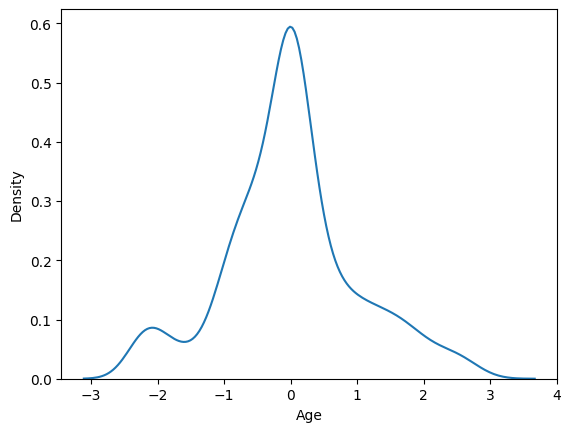

In [69]:
sns.kdeplot(data = X_train, x='Age')

## MinMax Scaling

<Axes: xlabel='Fare', ylabel='Density'>

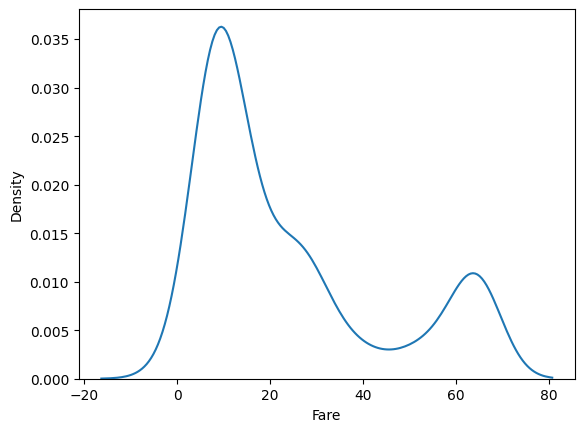

In [70]:
sns.kdeplot(data=X_train, x='Fare')

In [73]:
mms = MinMaxScaler()

mms.fit(X_train[['Fare']])

X_train['Fare'] = mms.transform(X_train[['Fare']]).ravel()
X_test['Fare'] = mms.transform(X_test[['Fare']]).ravel()

In [74]:
X_train['Fare']

331    0.442804
733    0.201981
382    0.123131
704    0.122031
813    0.485920
         ...   
106    0.118858
270    0.481647
860    0.219201
435    1.000000
102    1.000000
Name: Fare, Length: 707, dtype: float64

<Axes: xlabel='Fare', ylabel='Density'>

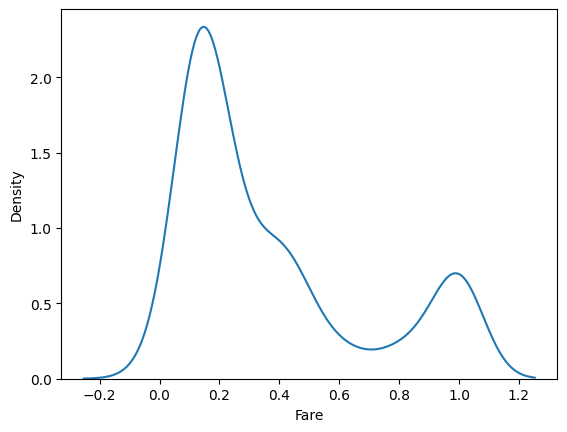

In [75]:
sns.kdeplot(data=X_train, x='Fare')